# Set Up

In [70]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [71]:
experiments = [
    "famfold",
    "hc_100",
    "hc_200",
    "hc_400",
    "rnadist_100",
    "rnadist_200",
    "rnadist_400",
    "samples_100",
    "samples_200",
    "samples_400",
]
palette = {
    "rnadist_100": "#7C87E9",
    "rnadist_200": "#2534BB",
    "rnadist_400": "#09157E",
    "samples_100": "#F189F5",
    "samples_200": "#A42E8A",
    "samples_400": "#8E0638",
    "hc_100": "#67DD67",
    "hc_200": "#0F690F",
    "hc_400": "#1a921a",
    "famfold": "#b3500e",
    "rna-llm": "gray",
}

In [72]:
rna_llm_OH_ref = {
    "tRNA": 0.46,
    "5s": 0.28,
    "tmRNA": 0.17,
    "RNaseP": 0.17,
    "srp": 0.15,
    "grp1": 0.15,
    "23s": 0.18,
    "16s": 0.16,
    "telomerase": 0.13,
}


# Crear DataFrame para sincfold
df_OH_rna_llm = pd.DataFrame(
    {
        "fam": list(rna_llm_OH_ref.keys()),
        "f1": list(rna_llm_OH_ref.values()),
        "modelo": "rna_llm_OneHot",
    }
)

# One Hot Encoding Best Epochs


In [73]:
df = pd.read_csv("SILVER/test_tables/OneHot_best_epochs_test.csv", index_col=0)
df.reset_index(inplace=True)
df.rename(columns={"index": "fam"}, inplace=True)
df

,fam,famfold,hc_100,hc_200,hc_400,rnadist_100,rnadist_200,rnadist_400,samples_100,samples_200,samples_400
0,16s,0.165955,0.176790,0.172565,0.171790,0.177671,0.175496,0.169992,0.171138,0.178608,0.177726
1,23s,0.217960,0.248963,0.254859,0.248073,0.238278,0.247058,0.246407,0.232445,0.231196,0.236537
2,5s,0.302964,0.274507,0.307439,0.323110,0.266982,0.287368,0.301740,0.285278,0.305465,0.307986
3,RNaseP,0.195204,0.231968,0.218198,0.218840,0.229668,0.222811,0.219416,0.225096,0.220527,0.213932
4,grp1,0.175828,0.191304,0.194980,0.193430,0.193354,0.192913,0.188268,0.188964,0.192502,0.190311
5,srp,0.177119,0.165824,0.174182,0.177704,0.174751,0.175871,0.175378,0.164127,0.175347,0.170907
6,tRNA,0.486793,0.374455,0.430655,0.464125,0.375334,0.443897,0.472553,0.438860,0.461141,0.476082
7,telomerase,0.129577,0.148743,0.146850,0.147367,0.146255,0.157299,0.145202,0.161353,0.143783,0.145757
8,tmRNA,0.179820,0.194391,0.206641,0.201923,0.202114,0.206749,0.201115,0.207295,0.208426,0.202421


In [74]:
def normalizar_y_melt(df, rna_llm, experiments):
    rna_llm_series = pd.Series(rna_llm)
    df_norm = df.copy()
    cols_to_normalize = [col for col in df.columns if col != "fam"]

    # Normalizar cada columna (vectorizado)
    df_norm[cols_to_normalize] = df_norm[cols_to_normalize].div(
        df_norm["fam"].map(rna_llm_series), axis=0
    )

    # Transformar a formato long
    dfn = df_norm.melt(
        id_vars="fam",
        value_vars=experiments,
        var_name="modelo",
        value_name="f1",
    )

    return dfn


# Transformar a formato long
dfl = df.melt(
    id_vars="fam",
    value_vars=experiments,
    var_name="modelo",
    value_name="f1",
)

dfn = normalizar_y_melt(df, rna_llm_OH_ref, experiments)

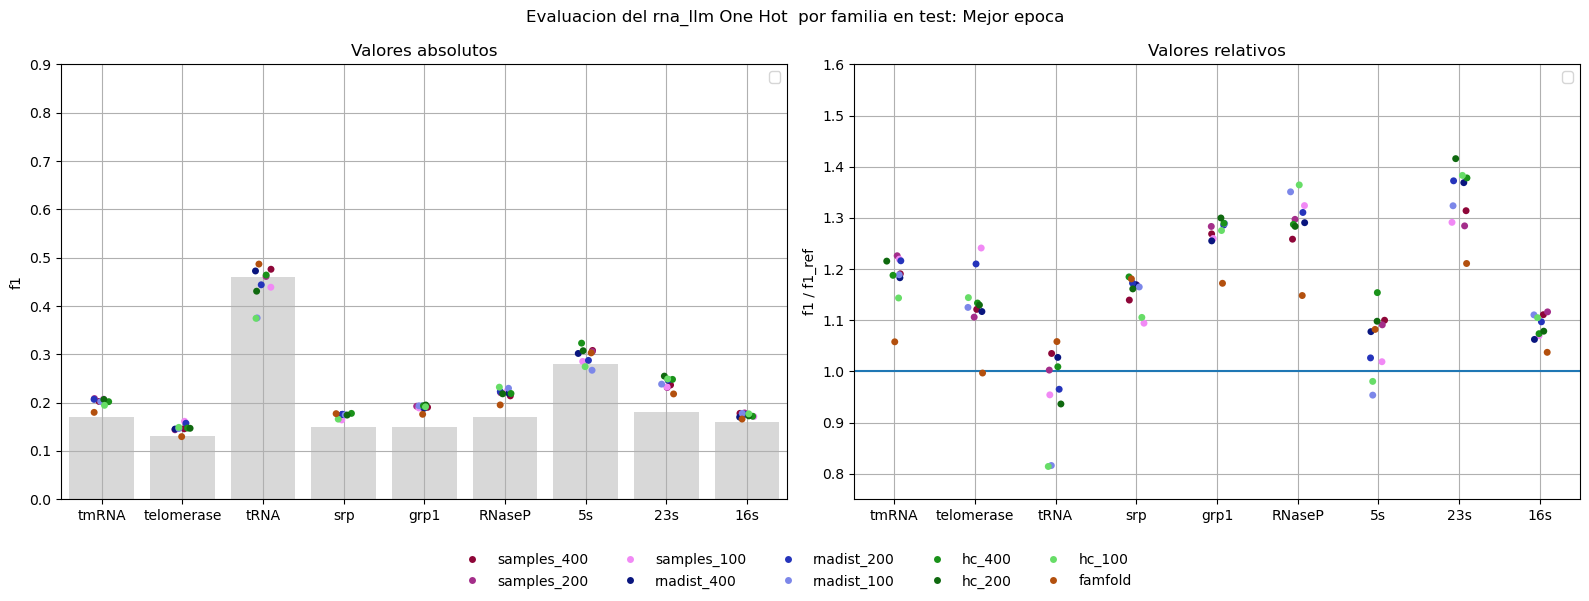

In [75]:
# Visualización categórica
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.stripplot(
    data=dfl.sort_values(by="modelo", ascending=False),
    x="fam",
    y="f1",
    hue="modelo",
    palette=palette,
    ax=axes[0],
)

sns.barplot(
    data=df_OH_rna_llm,
    x="fam",
    y="f1",
    color="gray",
    alpha=0.3,
    errorbar=None,
    ax=axes[0],
    legend=False,
)


sns.stripplot(
    data=dfn.sort_values(by="modelo", ascending=False),
    x="fam",
    y="f1",
    hue="modelo",
    palette=palette,
    ax=axes[1],
)

axes[0].set_ylim(0, 0.9)
axes[1].set_ylim(0.75, 1.6)
axes[0].grid()
axes[0].legend([])
axes[1].legend([])
axes[0].set_xlabel("")
plt.grid()
axes[0].set_title("Valores absolutos")
axes[1].set_title("Valores relativos")
fig.suptitle("Evaluacion del rna_llm One Hot  por familia en test: Mejor epoca")
axes[1].set_ylabel("f1 / f1_ref")
axes[0].tick_params(axis="x", rotation=0)
axes[1].tick_params(axis="x", rotation=0)
axes[1].set_xlabel("")

axes[1].axhline(y=1)

# Leyenda global
handles, labels = [], []
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    handles += h
    labels += l
by_label = dict(zip(labels, handles))
fig.legend(
    by_label.values(), by_label.keys(), loc="lower center", ncol=5, frameon=False
)

plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()

In [76]:
s = dfn.groupby("modelo")["f1"].mean().sort_values().reset_index()
s = s.rename(columns={"f1": "rel_f1"})
s

,modelo,rel_f1
0,famfold,1.104902
1,hc_100,1.146167
2,rnadist_100,1.146959
3,samples_100,1.163607
4,samples_400,1.170916
5,rnadist_400,1.172363
6,samples_200,1.175083
7,hc_200,1.179819
8,rnadist_200,1.184008
9,hc_400,1.188633


# RiNALMo

In [77]:
rna_llm_RiNALMo_ref = {
    "tRNA": 0.87,
    "5s": 0.82,
    "tmRNA": 0.70,
    "RNaseP": 0.73,
    "srp": 0.63,
    "grp1": 0.64,
    "23s": 0.59,
    "16s": 0.51,
    "telomerase": 0.09,
}


# Crear DataFrame para sincfold
df_RiNALMo_rna_llm = pd.DataFrame(
    {
        "fam": list(rna_llm_RiNALMo_ref.keys()),
        "f1": list(rna_llm_RiNALMo_ref.values()),
        "modelo": "rna_llm_RiNALMo",
    }
)

In [78]:
df = pd.read_csv("SILVER/test_tables/RiNALMo_best_epochs_test.csv", index_col=0)
df.reset_index(inplace=True)
df.rename(columns={"index": "fam"}, inplace=True)
df

,fam,famfold,hc_100,hc_200,hc_400,rnadist_100,rnadist_200,rnadist_400,samples_100,samples_200,samples_400
0,16s,0.528892,0.441631,0.474158,0.525090,0.413338,0.474106,0.512192,0.432769,0.472590,0.563645
1,23s,0.606371,0.528655,0.550553,0.633745,0.517608,0.584345,0.595191,0.519056,0.582560,0.600184
2,5s,0.768991,0.746607,0.764104,0.777616,0.744527,0.755231,0.780014,0.779156,0.749145,0.759735
3,RNaseP,0.672326,0.559993,0.645640,0.631301,0.612839,0.648352,0.647001,0.589208,0.619332,0.634980
4,grp1,0.556711,0.521288,0.535939,0.556795,0.548789,0.558154,0.547126,0.507242,0.558426,0.579147
5,srp,0.594040,0.535034,0.593233,0.591578,0.552853,0.573320,0.577239,0.564554,0.574595,0.583805
6,tRNA,0.864434,0.844595,0.867271,0.875990,0.825141,0.858818,0.863043,0.841429,0.874955,0.862905
7,telomerase,0.112538,0.136816,0.129451,0.123962,0.125292,0.130671,0.138113,0.114192,0.113472,0.132021
8,tmRNA,0.637931,0.567253,0.625446,0.643279,0.570237,0.608031,0.658499,0.595996,0.627098,0.649080


In [79]:
# Transformar a formato long
dfl = df.melt(
    id_vars="fam",
    value_vars=experiments,
    var_name="modelo",
    value_name="f1",
)

dfn = normalizar_y_melt(df, rna_llm_RiNALMo_ref, experiments)

In [80]:
dfn

,fam,modelo,f1
0,16s,famfold,1.037043
1,23s,famfold,1.027747
2,5s,famfold,0.937794
3,RNaseP,famfold,0.920994
4,grp1,famfold,0.869861
...,...,...,...
85,grp1,samples_400,0.904918
86,srp,samples_400,0.926675
87,tRNA,samples_400,0.991845
88,telomerase,samples_400,1.466895


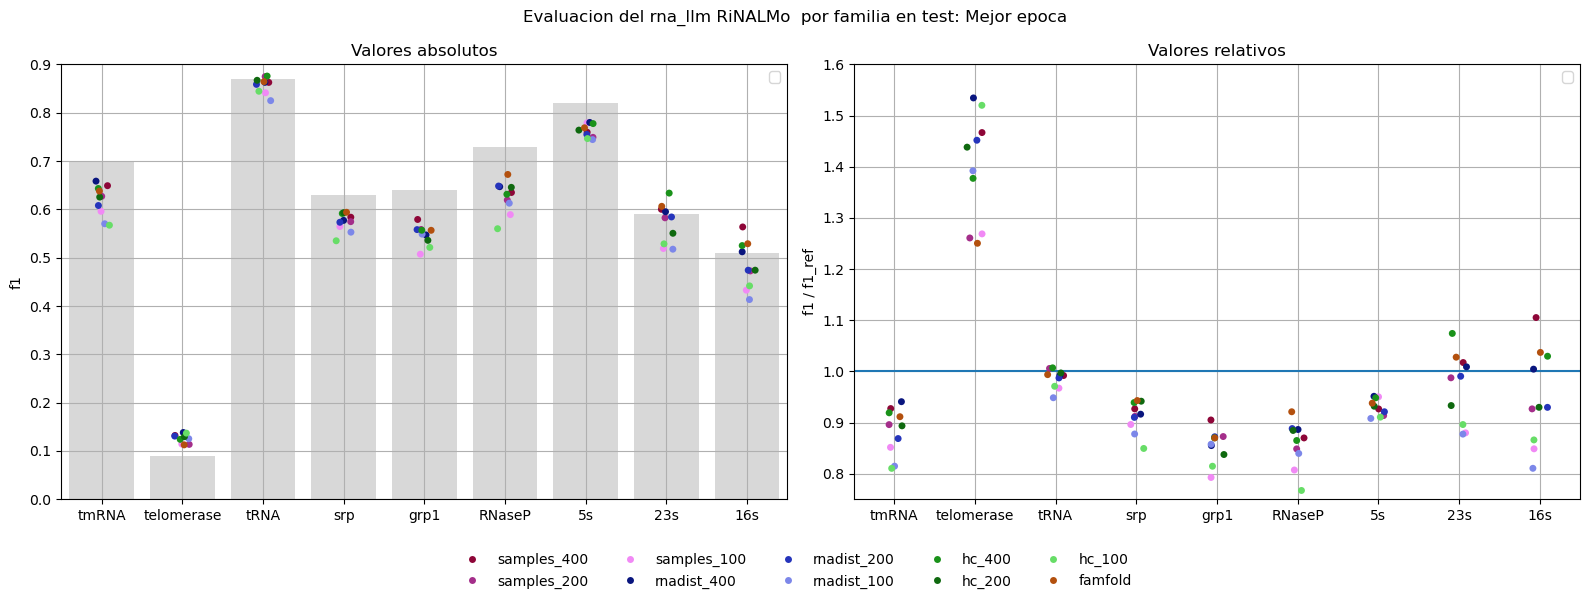

In [81]:
# Visualización categórica
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.stripplot(
    data=dfl.sort_values(by="modelo", ascending=False),
    x="fam",
    y="f1",
    hue="modelo",
    palette=palette,
    ax=axes[0],
)

sns.barplot(
    data=df_RiNALMo_rna_llm,
    x="fam",
    y="f1",
    color="gray",
    alpha=0.3,
    errorbar=None,
    ax=axes[0],
    legend=False,
)


sns.stripplot(
    data=dfn.sort_values(by="modelo", ascending=False),
    x="fam",
    y="f1",
    hue="modelo",
    palette=palette,
    ax=axes[1],
)

axes[0].set_ylim(0, 0.9)
axes[1].set_ylim(0.75, 1.6)
axes[0].grid()
axes[0].legend([])
axes[1].legend([])
axes[0].set_xlabel("")
plt.grid()
axes[0].set_title("Valores absolutos")
axes[1].set_title("Valores relativos")
fig.suptitle("Evaluacion del rna_llm RiNALMo  por familia en test: Mejor epoca")
axes[1].set_ylabel("f1 / f1_ref")
axes[0].tick_params(axis="x", rotation=0)
axes[1].tick_params(axis="x", rotation=0)
axes[1].set_xlabel("")

axes[1].axhline(y=1)

# Leyenda global
handles, labels = [], []
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    handles += h
    labels += l
by_label = dict(zip(labels, handles))
fig.legend(
    by_label.values(), by_label.keys(), loc="lower center", ncol=5, frameon=False
)

plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()

In [82]:
s = dfn.groupby("modelo")["f1"].mean().sort_values().reset_index()
s = s.rename(columns={"f1": "rel_f1"})
s

,modelo,rel_f1
0,samples_100,0.917969
1,rnadist_100,0.925050
2,hc_100,0.933854
3,samples_200,0.958109
4,hc_200,0.976320
5,rnadist_200,0.979890
6,famfold,0.987968
7,hc_400,1.003228
8,rnadist_400,1.009898
9,samples_400,1.015153
